# Fairness Analysis

With the labels predicted in the test sample of the predictive analysis, the **Aequitas** toolkit is used to assess the fairness of the model's predictions across different demographic and health-related groups.

Fairness analysis helps identify whether a predictive model performs differently for certain groups of individuals, which could lead to biased outcomes.

In this section we:
- Prepare the dataset for fairness evaluation
- Compute fairness metrics using Aequitas
- Compare disparities across different demographic and health attributes
- Visualize disparities using tree maps

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

import aequitas as aq
from aequitas.plotting import Plot
from aequitas.group import Group
from aequitas.bias import Bias
from aequitas.fairness import Fairness
import aequitas.plot as ap

In [2]:
diab_df = pd.read_csv('/Users/louisbarthelemy/Library/Mobile Documents/com~apple~CloudDocs/Mines Paris/3A/cookiecutter-data-science/Diabetes_prediction/data/diabetes_with_predicted_labels.csv')
diab_df.head()

,Unnamed: 0,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,CholxCheck,BMIxChol,IncomexAge,BPxAge,BPxChol,AgexBMI,AgexGenHlth,label_value,score,BMI_categorical
0,172554,0.0,0.0,1.0,1.0,26.0,0.0,0.0,0.0,1.0,...,1.0,26.0,0.500000,0.0,0.0,104.0,4.0,0.0,0.0,Overweight
1,105742,2.0,1.0,1.0,1.0,16.0,0.0,0.0,1.0,1.0,...,1.0,16.0,1.714286,12.0,1.0,192.0,36.0,1.0,1.0,Underweight
2,149087,2.0,1.0,1.0,1.0,26.0,1.0,0.0,1.0,0.0,...,1.0,26.0,1.571429,11.0,1.0,286.0,55.0,1.0,1.0,Overweight
3,145979,0.0,0.0,0.0,1.0,31.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.875000,0.0,0.0,217.0,14.0,0.0,0.0,Obesity Class I
4,239661,2.0,1.0,1.0,1.0,42.0,1.0,0.0,1.0,0.0,...,1.0,42.0,5.000000,5.0,1.0,210.0,20.0,1.0,1.0,Severe Obesity


In [3]:
diab_df["BPxChol"] = diab_df["HighBP"] * diab_df["HighChol"]

diab_df = diab_df[["BPxChol", "Age", "GenHlth", "BMI", "Income", "Diabetes_012"]]

diab_df["Diabetes_012"] = diab_df["Diabetes_012"].replace(2, 1)

features = ["BPxChol", "Age", "GenHlth", "BMI"]

diab_model_df = diab_df[["Diabetes_012"] + features]

X = diab_model_df.drop(columns=["Diabetes_012"])
y = diab_model_df["Diabetes_012"]

undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train[features])
X_test_sc = scaler.transform(X_test[features])

In [4]:
model = RandomForestClassifier(
    criterion="gini",
    max_features='sqrt',
    max_leaf_nodes=16,
    max_depth=6,
    n_estimators=100
)

In [5]:
# assess model performance with cross-validation
scoring = ['accuracy', 'f1_macro']
scores = cross_validate(model, X_train_sc, y_train, cv=5, scoring=scoring)

model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

## Fairness Preprocessing

Some variables contain many categories that make fairness analysis difficult to interpret.  
To simplify the analysis:

- **Age** is grouped into bins
- **Income** is grouped into broader ranges

This allows the fairness metrics to be evaluated across meaningful demographic groups.

## Feature Selection

Only the features relevant for fairness analysis are kept in the dataset:

- Prediction score
- True label
- Age
- BMI category
- Blood Pressure × Cholesterol
- General Health
- Income

In [6]:
df_aq = diab_df.loc[X_test.index].copy() 
df_aq["score"] = y_pred
df_aq = df_aq.rename(columns={"Diabetes_012" : "label_value"})

In [7]:
# Data Preprocessing to have less categories
df_aq['Age'] = pd.cut(df_aq['Age'], bins=[0, 2, 4, 6, 8, 10, 13], 
                   labels=['0-2', '2-4', '4-6', '6-8', '8-10', '10-13'])

df_aq['Income'] = pd.cut(df_aq['Income'], bins=[1, 3, 5, 6, 8], 
                      labels=['1-2', '3-4', '5-6', '7-8'], include_lowest=True)

df_aq['BMI_categorical'] = pd.cut(df_aq['BMI'], bins=[0, 18.5, 25, 30, 35, 40, 100], 
                                     labels=["Underweight", "Healthy", "Overweight", "Obesity Class I",
          "Obesity Class II", "Severe Obesity"], include_lowest=True)

In [8]:
# Selection of the features used in the predictive analysis
df_aq = df_aq[['score', 'label_value', 'Age', 'BMI_categorical', 
         'BPxChol', 'GenHlth', 'Income']]

## Data Type Formatting

Aequitas requires categorical attributes to be stored as **string values**.  
Therefore, all categorical columns are converted to strings while prediction score and labels remain numerical.

In [9]:
# Convert categorical columns to string
non_string_cols = df_aq.columns[(df_aq.dtypes != object) & (df_aq.dtypes != str)]
df_aq[non_string_cols] = df_aq[non_string_cols].astype(str)

df_aq['score'] = df_aq['score'].astype(float)
df_aq['label_value'] = df_aq['label_value'].astype(float)

## Group Metrics Calculation

Aequitas first computes **group-level performance metrics** using cross-tabulations.

These metrics include:
- Precision
- Recall
- False positive rate
- True positive rate

The metrics are calculated separately for each value of each attribute.

In [10]:
group = Group()
xtab, _ = group.get_crosstabs(df_aq)

absolute_metrics = group.list_absolute_metrics(xtab)

xtab[['attribute_name', 'attribute_value'] + absolute_metrics].round(2)

,attribute_name,attribute_value,tpr,tnr,for,fdr,fpr,fnr,npv,precision,ppr,pprev,prev
0,Age,0-2,0.18,0.95,0.10,0.67,0.05,0.82,0.90,0.33,0.00,0.06,0.11
1,Age,10-13,0.83,0.41,0.42,0.30,0.59,0.17,0.58,0.70,0.33,0.74,0.63
2,Age,2-4,0.50,0.91,0.12,0.43,0.09,0.50,0.88,0.57,0.02,0.17,0.20
3,Age,4-6,0.75,0.82,0.13,0.34,0.18,0.25,0.87,0.66,0.08,0.37,0.32
4,Age,6-8,0.75,0.69,0.23,0.34,0.31,0.25,0.77,0.66,0.21,0.51,0.45
5,Age,8-10,0.85,0.60,0.27,0.25,0.40,0.15,0.73,0.75,0.36,0.66,0.59
6,BMI_categorical,Healthy,0.58,0.83,0.17,0.42,0.17,0.42,0.83,0.58,0.14,0.29,0.29
7,BMI_categorical,Obesity Class I,0.86,0.49,0.34,0.25,0.51,0.14,0.66,0.75,0.29,0.73,0.64
8,BMI_categorical,Obesity Class II,0.91,0.37,0.38,0.21,0.63,0.09,0.62,0.79,0.14,0.84,0.72
9,BMI_categorical,Overweight,0.76,0.69,0.22,0.34,0.31,0.24,0.78,0.66,0.32,0.51,0.44


## Bias and Disparity Analysis

Disparity metrics measure how different a group’s performance is compared to a **reference group**.

In this analysis, the reference group represents **healthy individuals with average demographic characteristics** within the dataset.

Reference group characteristics:

- **Age:** `6–8` (approximately 45–54 years old)
- **BMI:** `Healthy`
- **Blood Pressure × Cholesterol:** `0.0`
- **General Health:** `2.0` (out of 5 bins)
- **Income:** `3–4` (approximately \$20,000–\$25,000 yearly)

Disparity coefficients equal **1** for the reference group because all other groups are compared against it.

In [11]:
bias = Bias()

bias_df = bias.get_disparity_predefined_groups(
    xtab,
    original_df=df_aq,
    ref_groups_dict={
        'Age': '6-8',
        'BMI_categorical': 'Healthy',
        'BPxChol': '0.0',
        'GenHlth': '2.0',
        'Income': '3-4'
    },
    alpha=0.05,
    check_significance=True,
    mask_significance=True
)

bias_df.style

get_disparity_predefined_group()


/Users/louisbarthelemy/Library/Mobile Documents/com~apple~CloudDocs/Mines Paris/3A/cookiecutter-data-science/Diabetes_prediction/diabetes/lib/python3.12/site-packages/aequitas/bias.py:449: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[True, True, True, True, False, True, False, True, True, True, True, False, False, True, True, False, True, True, True, True, False, True, True]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[:, significance_cols] = np.select(
/Users/louisbarthelemy/Library/Mobile Documents/com~apple~CloudDocs/Mines Paris/3A/cookiecutter-data-science/Diabetes_prediction/diabetes/lib/python3.12/site-packages/aequitas/bias.py:449: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[True, True, True, True, False, True, False, True, True, True, True, False, False, True, True, False, True,

,model_id,score_threshold,k,attribute_name,attribute_value,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev,label_value_significance,score_significance,fdr_disparity,fdr_ref_group_value,fdr_significance,fnr_disparity,fnr_ref_group_value,fnr_significance,for_disparity,for_ref_group_value,for_significance,fpr_disparity,fpr_ref_group_value,fpr_significance,npv_disparity,npv_ref_group_value,npv_significance,ppr_disparity,ppr_ref_group_value,ppr_significance,pprev_disparity,pprev_ref_group_value,pprev_significance,precision_disparity,precision_ref_group_value,precision_significance,tnr_disparity,tnr_ref_group_value,tnr_significance,tpr_disparity,tpr_ref_group_value,tpr_significance
0,0,binary 0/1,1558,Age,0-2,0.181818,0.954023,0.097826,0.666667,0.045977,0.818182,0.902174,0.333333,6,92,0.003851,0.061224,4,9,83,2,11,87,98,2804,0.112245,True,True,1.981481,6-8,False,3.272727,6-8,True,0.431261,6-8,True,0.149000,6-8,False,1.166861,6-8,True,0.018692,6-8,True,0.120923,6-8,True,0.502347,6-8,False,1.379785,6-8,False,0.242424,6-8,True
1,0,binary 0/1,1558,Age,10-13,0.826577,0.409962,0.418478,0.295585,0.590038,0.173423,0.581522,0.704415,521,184,0.334403,0.739007,154,77,107,367,444,261,705,2804,0.629787,True,True,0.878546,6-8,False,0.693694,6-8,True,1.844841,6-8,True,1.912161,6-8,False,0.752133,6-8,True,1.623053,6-8,True,1.459597,6-8,True,1.061583,6-8,False,0.592920,6-8,False,1.102102,6-8,True
2,0,binary 0/1,1558,Age,2-4,0.500000,0.908537,0.118343,0.428571,0.091463,0.500000,0.881657,0.571429,35,169,0.022465,0.171569,15,20,149,20,40,164,204,2804,0.196078,True,True,1.273810,6-8,False,2.000000,6-8,True,0.521710,6-8,True,0.296409,6-8,False,1.140325,6-8,True,0.109034,6-8,True,0.338861,6-8,True,0.861167,6-8,False,1.313999,6-8,False,0.666667,6-8,True
3,0,binary 0/1,1558,Age,4-6,0.747573,0.815668,0.128079,0.341880,0.184332,0.252427,0.871921,0.658120,117,203,0.075096,0.365625,40,26,177,77,103,217,320,2804,0.321875,True,True,1.016144,6-8,False,1.009709,6-8,True,0.564629,6-8,True,0.597372,6-8,False,1.127733,6-8,True,0.364486,6-8,True,0.722138,6-8,True,0.991814,6-8,False,1.179685,6-8,False,0.996764,6-8,True
4,0,binary 0/1,1558,Age,6-8,0.750000,0.691429,0.226837,0.336449,0.308571,0.250000,0.773163,0.663551,321,313,0.206033,0.506309,108,71,242,213,284,350,634,2804,0.447950,False,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False
5,0,binary 0/1,1558,Age,8-10,0.847082,0.604046,0.266667,0.245520,0.395954,0.152918,0.733333,0.754480,558,285,0.358151,0.661922,137,76,209,421,497,346,843,2804,0.589561,True,True,0.729739,6-8,True,0.611670,6-8,False,1.175587,6-8,False,1.283183,6-8,True,0.948485,6-8,False,1.738318,6-8,True,1.307347,6-8,True,1.137034,6-8,True,0.873621,6-8,True,1.129443,6-8,False
6,0,binary 0/1,1558,BMI_categorical,Healthy,0.580952,0.828516,0.169884,0.421801,0.171484,0.419048,0.830116,0.578199,211,518,0.135430,0.289438,89,88,430,122,210,519,729,2804,0.288066,False,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False
7,0,binary 0/1,1558,BMI_categorical,Obesity Class I,0.859694,0.486486,0.337423,0.252772,0.513514,0.140306,0.662577,0.747228,451,163,0.289474,0.734528,114,55,108,337,392,222,614,2804,0.638436,True,True,0.599268,Healthy,True,0.334821,Healthy,True,1.986196,Healthy,True,2.994534,Healthy,True,0.798174,Healthy,True,2.137441,Healthy,True,2.537776,Healthy,True,1.292338,Healthy,True,0.587178,Healthy,True,1.479801,Healthy,True
8,0,binary 0/1,1558,BMI_categorical,Obesity Class II,0.913043,0.366197,0.380952,0.211268,0.633803,0.086957,0.619048,0.788732,213,42,0.136714,0.835294,45,16,26,168,184,71,255,2804,0.721569,True,True,0.500870,Healthy,True,0.207510,H

## Disparity Metrics Overview

The following table shows disparity metrics and their statistical significance.

These values indicate how far each group's prediction performance deviates from the reference group.

In [12]:
bias_df[['attribute_name', 'attribute_value'] +
        bias.list_disparities(bias_df) +
        bias.list_significance(bias_df)].style

,attribute_name,attribute_value,fdr_disparity,fnr_disparity,for_disparity,fpr_disparity,npv_disparity,ppr_disparity,pprev_disparity,precision_disparity,tnr_disparity,tpr_disparity,label_value_significance,score_significance,fdr_significance,fnr_significance,for_significance,fpr_significance,npv_significance,ppr_significance,pprev_significance,precision_significance,tnr_significance,tpr_significance
0,Age,0-2,1.981481,3.272727,0.431261,0.149000,1.166861,0.018692,0.120923,0.502347,1.379785,0.242424,True,True,False,True,True,False,True,True,True,False,False,True
1,Age,10-13,0.878546,0.693694,1.844841,1.912161,0.752133,1.623053,1.459597,1.061583,0.592920,1.102102,True,True,False,True,True,False,True,True,True,False,False,True
2,Age,2-4,1.273810,2.000000,0.521710,0.296409,1.140325,0.109034,0.338861,0.861167,1.313999,0.666667,True,True,False,True,True,False,True,True,True,False,False,True
3,Age,4-6,1.016144,1.009709,0.564629,0.597372,1.127733,0.364486,0.722138,0.991814,1.179685,0.996764,True,True,False,True,True,False,True,True,True,False,False,True
4,Age,6-8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,False,False,False,False,False,False,False,False,False,False,False,False
5,Age,8-10,0.729739,0.611670,1.175587,1.283183,0.948485,1.738318,1.307347,1.137034,0.873621,1.129443,True,True,True,False,False,True,False,True,True,True,True,False
6,BMI_categorical,Healthy,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,False,False,False,False,False,False,False,False,False,False,False,False
7,BMI_categorical,Obesity Class I,0.599268,0.334821,1.986196,2.994534,0.798174,2.137441,2.537776,1.292338,0.587178,1.479801,True,True,True,True,True,True,True,True,True,True,True,True
8,BMI_categorical,Obesity Class II,0.500870,0.207510,2.242424,3.695996,0.745736,1.009479,2.885921,1.364119,0.441991,1.571632,True,True,True,True,True,True,True,True,True,True,True,True
9,BMI_categorical,Overweight,0.807788,0.575828,1.291523,1.828417,0.940340,2.350711,1.766668,1.140220,0.828537,1.305960,True,True,True,True,True,True,True,True,True,True,True,True


## Precision Disparities

The visualization below displays **precision disparities** across feature groups.

Each square in the tree map:
- Represents a demographic group
- Has an area proportional to its population size
- Uses color to indicate disparity magnitude relative to the reference group

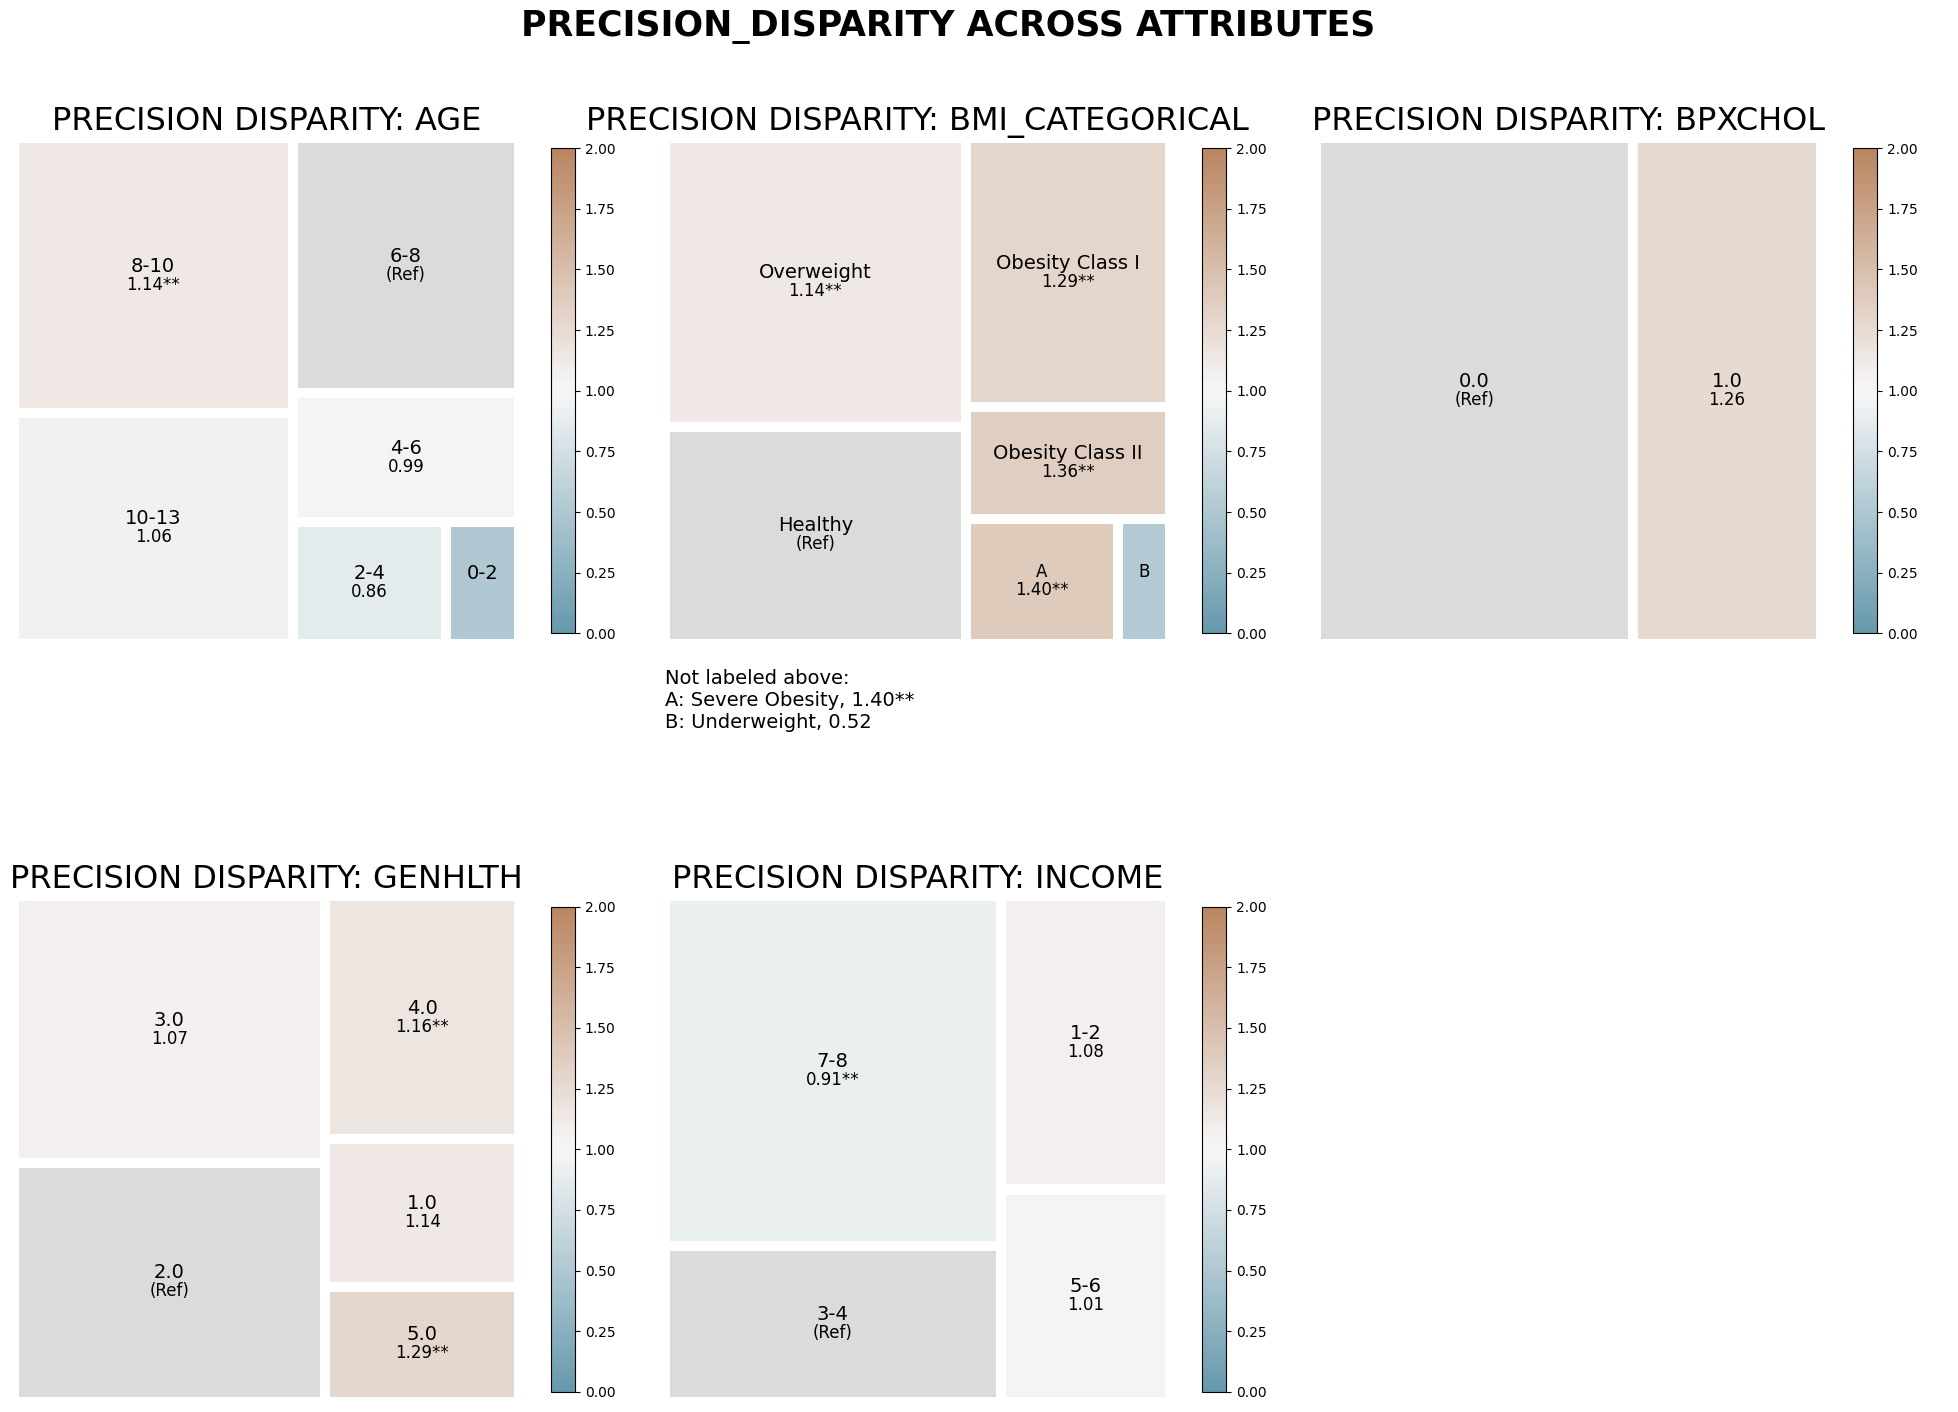

In [13]:
plot = Plot()
j = plot.plot_disparity_all(bias_df, metrics=['precision_disparity'], significance_alpha=0.05)

### Interpretation of Precision Disparities

The precision disparity visualization shows that the model generally has a similar ability to correctly predict positive diabetes cases across most **income and age groups**.

However:

- Precision is **lower for very young patients**, who represent a small portion of the dataset.
- Patients with **high blood pressure and cholesterol** also show lower precision.

A clear pattern appears for **BMI and general health categories**:

- The **higher the BMI**,
- The **worse the general health**

the **higher the precision** of the model.

This indicates that the model is better at predicting true positives (with fewer false positives) for individuals who already have significant health issues.

## True Positive Rate (Sensitivity) Disparities

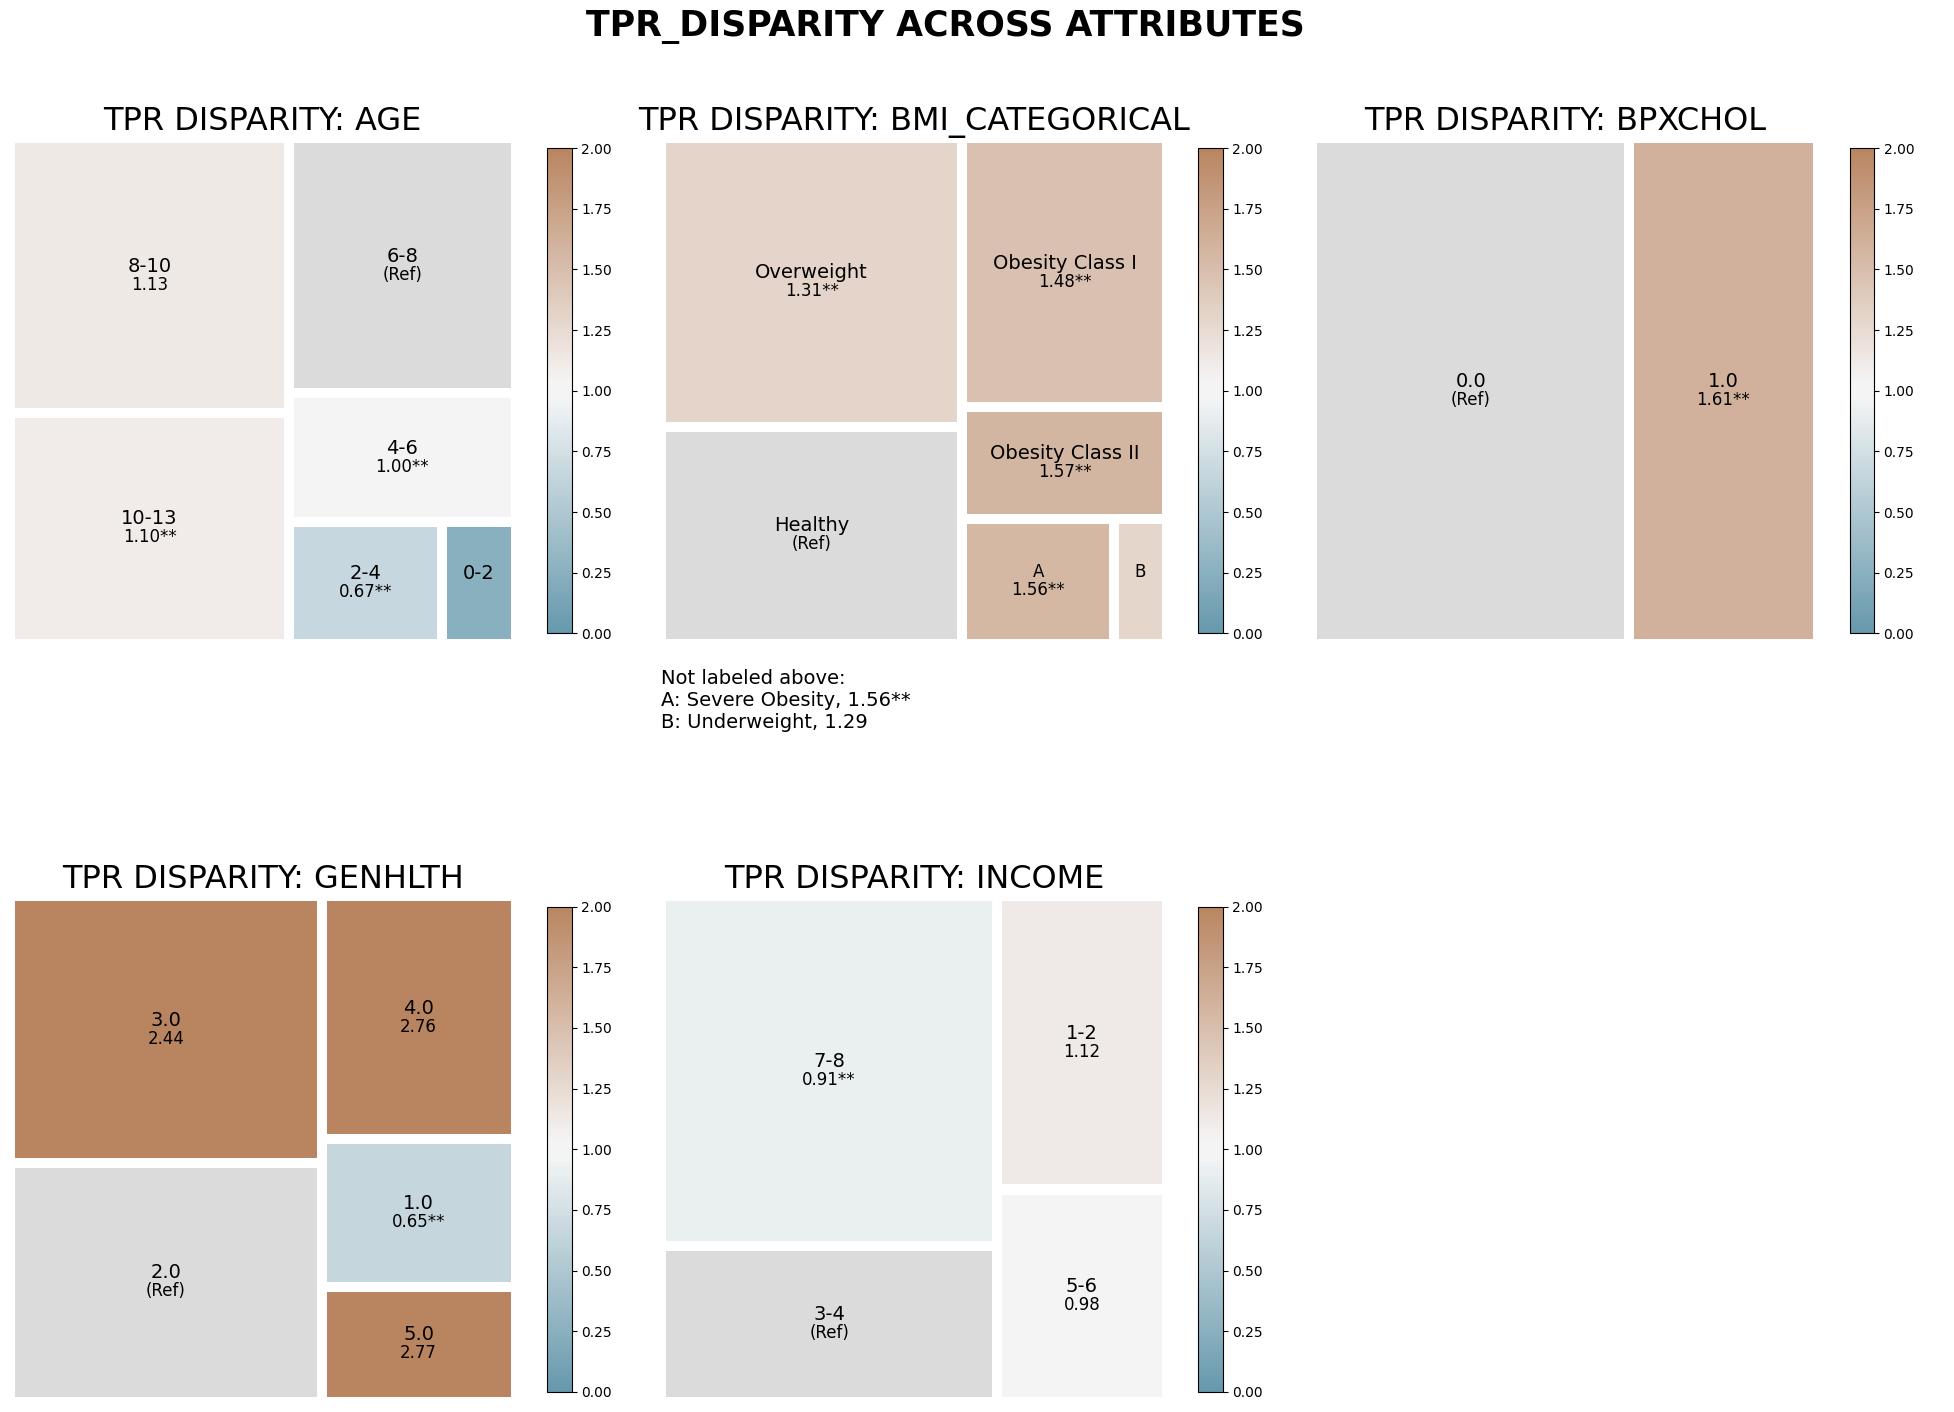

In [14]:
j = plot.plot_disparity_all(bias_df, metrics=['tpr_disparity'], significance_alpha=0.05)

### Interpretation of Sensitivity Disparities

The **True Positive Rate (TPR)** visualizations reveal a significant bias: the model is far more likely to correctly identify diabetes in patients who already exhibit high-risk health markers.

- **Health Indicators:** Patients with poor general health, high BMI, or high blood pressure/cholesterol have **1.5× to 2.77× higher sensitivity** than healthier reference groups.

- **Age:** The model is most accurate for older groups but significantly misses cases in the **2–4 age bracket** (**0.67× disparity**).

- **Income:** This is the most equitable feature, though **high-income earners** are slightly less likely (**0.91×**) to be correctly detected by the model.

The model relies heavily on **“sickness proxies.”** While it effectively identifies high-risk individuals with existing comorbidities, it frequently fails to detect diabetes in **younger or otherwise “healthier-looking” patients**.

## Key Findings

Combining the precision and sensitivity analyses highlights several important fairness concerns.
The model appears to discriminate against individuals who are generally healthy, particularly **younger patients**.

For these groups:

- Precision is lower, meaning they are **more likely to be incorrectly predicted as diabetic**.
- Sensitivity is also significantly lower, meaning **actual diabetic cases are more likely to be missed**.

The most significant imbalance appears in **True Positive Rate disparities**, where healthier groups experience substantially lower recall.

One possible explanation for this limitation is the **absence of genetic or hereditary features** in the dataset, which could play a significant role in predicting diabetes for individuals without obvious health risk factors.